<a href="https://colab.research.google.com/github/DarrrkS/lab_ml_dl/blob/main/LR1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#ignore warnings
import warnings
warnings.filterwarnings('ignore')

url = 'https://drive.google.com/u/0/uc?id=1-TzMGAKLjS9RrYXSBWCAD0zAk-gd1pab&export=download'
data = pd.read_csv(url)
data.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Все значения признаков ненулевые, следовательно выбрасывать нечего.
Проверим на наличие дубликатов:

In [ ]:
print(len(data))
data.drop_duplicates(keep='first', inplace=True)
print(len(data))

1599
1359


Дубликаты удалены. Проверим корреляцию признаково между собой:

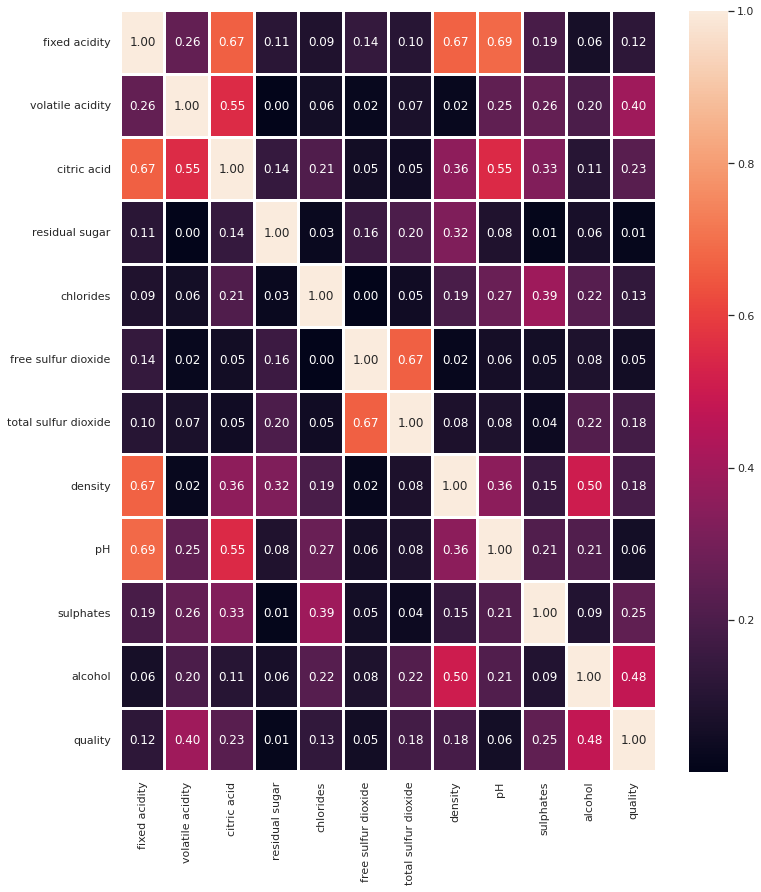

In [ ]:
import seaborn as sns
corr = data.corr().abs()
sns.set(rc={'figure.figsize':(12,14)})
sns.heatmap(corr, xticklabels=corr.columns.values, yticklabels=corr.columns.values, annot=True, fmt='.2f', linewidths=2)

Наблюдается некоторая корреляция признаков. Рассмотрим признаки с коррелирующим коэффициентом в диапазоне [0,6;1]

In [ ]:
corr_copy = corr.copy()
for row in corr_copy.index:
    for column in corr_copy[row].index: 
        if corr_copy[row][column] < 0.6: 
            corr_copy[row][column] = '---'
        else:
            corr_copy[row][column] = round(corr_copy[row][column], 2)

corr_copy

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1,---,0.67,---,---,---,---,0.67,0.69,---,---,---
volatile acidity,---,1,---,---,---,---,---,---,---,---,---,---
citric acid,0.67,---,1,---,---,---,---,---,---,---,---,---
residual sugar,---,---,---,1,---,---,---,---,---,---,---,---
chlorides,---,---,---,---,1,---,---,---,---,---,---,---
free sulfur dioxide,---,---,---,---,---,1,0.67,---,---,---,---,---
total sulfur dioxide,---,---,---,---,---,0.67,1,---,---,---,---,---
density,0.67,---,---,---,---,---,---,1,---,---,---,---
pH,0.69,---,---,---,---,---,---,---,1,---,---,---
sulphates,---,---,---,---,---,---,---,---,---,1,---,---


Удалим коррелирующие признаки: "citric acid", "density", "pH", "total sulfur dioxide".

In [ ]:
data_cleaned = data.drop(['citric acid', 'density', 'pH', 'total sulfur dioxide'], axis = 1)

In [ ]:
X = data_cleaned[data_cleaned.columns[:-1]]
y = data['quality']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y)


from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.47352941176470587

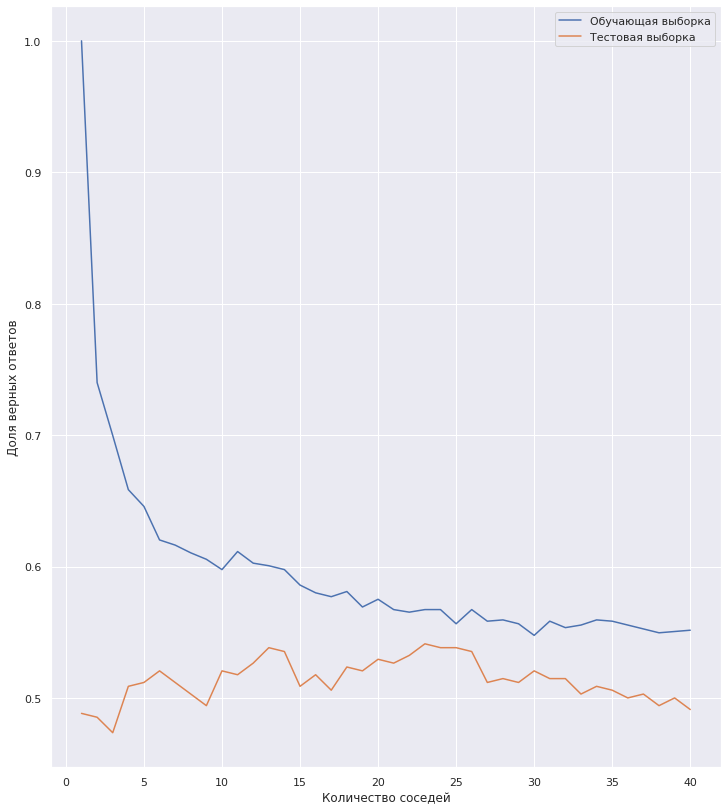

The value of the parameter "n_neighbors" in the KNN Classifier: 23
The max value of the metric "score" in the test sample: 0.5412


In [ ]:
train_scores = {}
test_scores = {}

for n in range(1,41):
  clf = KNeighborsClassifier(n_neighbors=n)
  clf.fit(X_train, y_train)
  train_scores[n] = clf.score(X_train, y_train)
  test_scores[n] = clf.score(X_test, y_test)

plt.plot(list(train_scores.keys()), list(train_scores.values()), label='Обучающая выборка')
plt.plot(list(test_scores.keys()), list(test_scores.values()), label='Тестовая выборка')
plt.xlabel('Количество соседей')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

index_max = max(test_scores, key=test_scores.get)
print(f'The value of the parameter "n_neighbors" in the KNN Classifier: {index_max}')
print(f'The max value of the metric "score" in the test sample: {round(test_scores[index_max], 4)}')

Не самый лучший результат, попробуем оверсэмплинг начальных данных со SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_sm, y_sm = smote.fit_sample(X, y)
X_sm.shape, y_sm.shape


((3462, 7), (3462,))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_sm,y_sm)


from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.7344110854503464

Видим, что точность уже заметно повысилась

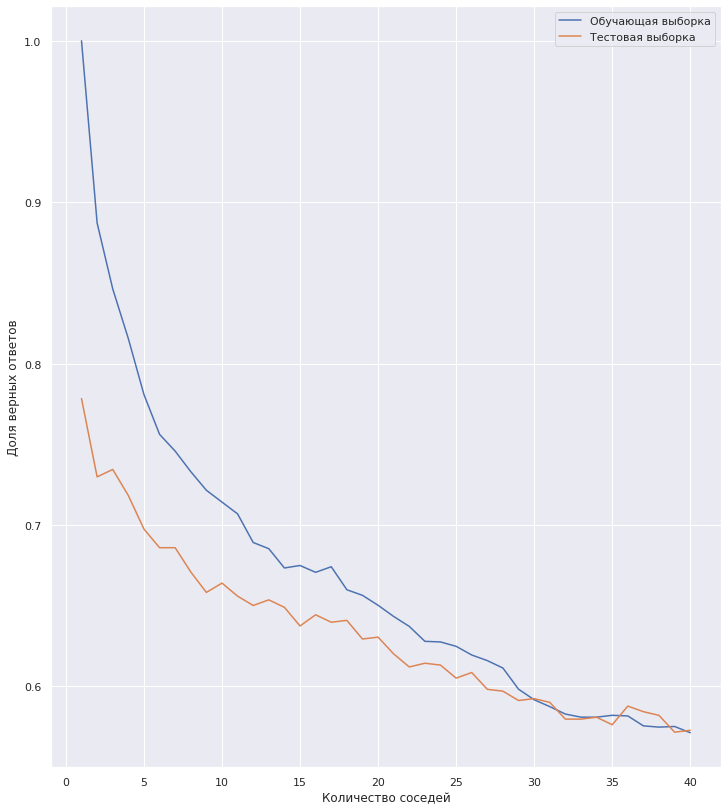

The value of the parameter "n_neighbors" in the KNN Classifier: 1
The max value of the metric "score" in the test sample: 0.7783


In [ ]:
train_scores = {}
test_scores = {}

for n in range(1,41):
  clf = KNeighborsClassifier(n_neighbors=n)
  clf.fit(X_train, y_train)
  train_scores[n] = clf.score(X_train, y_train)
  test_scores[n] = clf.score(X_test, y_test)
plt.plot(list(train_scores.keys()), list(train_scores.values()), label='Обучающая выборка')
plt.plot(list(test_scores.keys()), list(test_scores.values()), label='Тестовая выборка')
plt.xlabel('Количество соседей')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

index_max = max(test_scores, key=test_scores.get)
print(f'The value of the parameter "n_neighbors" in the KNN Classifier: {index_max}')
print(f'The max value of the metric "score" in the test sample: {round(test_scores[index_max], 4)}')